In [3]:
# Mountung google drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import numpy as np

In [5]:
# Loading the Essential datasets
orders_df = pd.read_csv('/content/drive/MyDrive/Amali/olist_orders_dataset.csv')
reviews_df = pd.read_csv('/content/drive/MyDrive/Amali/olist_order_reviews_dataset.csv')
customers_df = pd.read_csv('/content/drive/MyDrive/Amali/olist_customers_dataset.csv')
products_df = pd.read_csv('/content/drive/MyDrive/Amali/olist_products_dataset.csv')


In [6]:
# Loading helper dataset
order_items_df = pd.read_csv('/content/drive/MyDrive/Amali/olist_order_items_dataset.csv')
print(order_items_df.shape)
print(order_items_df.columns.tolist())

(112650, 7)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


# Inspecting the dataframes

In [7]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [9]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [11]:
# The orders dataset
print(orders_df.shape)
print(orders_df.isnull().sum())
print(orders_df['order_status'].value_counts())

(99441, 8)
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [13]:
# The reviews dataset
print(reviews_df.shape)
print(reviews_df.isnull().sum())
print(reviews_df['review_score'].value_counts().sort_index())

(99224, 7)
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [14]:
# The customers dataset
print(customers_df.shape)
print(customers_df.isnull().sum())

(99441, 5)
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [15]:
# The products dataset
print(products_df.shape)
print(products_df.isnull().sum())

(32951, 9)
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [16]:
print('\n Unique values')
print (orders_df["order_id"].nunique() == len(orders_df))
print (reviews_df["order_id"].nunique() == len(reviews_df))
print (customers_df["customer_id"].nunique() == len(customers_df))


 Unique values
True
False
True


# Joining The Tables

In [18]:
# Joining Orders + Customers on customer_id
master_df = orders_df.merge(customers_df, on='customer_id', how='left')
print(f"After orders + customers: {master_df.shape}")

# STEP 3: Join + Review on order_id
master_df = master_df.merge(reviews_df, on='order_id', how='left')
print(f"After + reviews: {master_df.shape}")

# STEP 4: Joining + Order Items ( the bridge dataset) and then + Products
# Agreggating order_items to one row per order BEFORE joining
order_items_agg = order_items_df.groupby('order_id').agg(
    product_id=('product_id', 'first'),
    order_item_count=('order_item_id', 'count')
).reset_index()

master_df = master_df.merge(order_items_agg, on='order_id', how='left')
print(f"After + order_items: {master_df.shape}")

# Joining then to Products on product_id
master_df = master_df.merge(products_df[['product_id', 'product_category_name']],
                             on='product_id', how='left')
print(f"After + products: {master_df.shape}")

print("\nFinal columns:")
print(master_df.columns.tolist())

After orders + customers: (99441, 12)
After + reviews: (99992, 18)
After + order_items: (99992, 20)
After + products: (99992, 21)

Final columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'product_id', 'order_item_count', 'product_category_name']


# Cleaning The Resulting Dataset For Reliability

In [21]:
# Fixing duplicate rows due to one to many reviews (keeping latest review per order)

# First, converting review_creation_date to datetime so we can sort it
master_df['review_creation_date'] = pd.to_datetime(master_df['review_creation_date'])

# Sort by order_id and review date, keep the most recent review
master_df = master_df.sort_values('review_creation_date', ascending=False)
master_df = master_df.drop_duplicates(subset='order_id', keep='first')

print(f"After removing duplicates: {master_df.shape}")

After removing duplicates: (99441, 21)


In [22]:
# Fixing orders where the status is not delivered since they can't be classified in relation to our problem

# First, filtering to delivered orders only
master_df = master_df[master_df['order_status'] == 'delivered'].copy()
print(f"Delivered orders only: {master_df.shape}")

# Then, converting date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    master_df[col] = pd.to_datetime(master_df[col])

print("Date columns converted:")
print(master_df[date_cols].dtypes)

# Dropping rows where delivery date is null
master_df = master_df.dropna(subset=['order_delivered_customer_date'])
print(f"After dropping null delivery dates: {master_df.shape}")

# Calculating delay in days
master_df['days_difference'] = (
    master_df['order_estimated_delivery_date'] -
    master_df['order_delivered_customer_date']
).dt.days

print("\nDelay stats:")
print(master_df['days_difference'].describe())

# Classifying delivery status
def classify_delivery(days):
    if days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

master_df['delivery_status'] = master_df['days_difference'].apply(classify_delivery)

print("\nDelivery status breakdown:")
print(master_df['delivery_status'].value_counts())

Delivered orders only: (96478, 21)
Date columns converted:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
After dropping null delivery dates: (96470, 21)

Delay stats:
count    96470.000000
mean        10.875889
std         10.182105
min       -189.000000
25%          6.000000
50%         11.000000
75%         16.000000
max        146.000000
Name: days_difference, dtype: float64

Delivery status breakdown:
delivery_status
On Time       88644
Super Late     4211
Late           3615
Name: count, dtype: int64


In [23]:
# GEOGRAPHIC ANALYSIS: Late % per State

# Creating a flag for late orders
master_df['is_late'] = master_df['delivery_status'].isin(['Late', 'Super Late']).astype(int)

# Aggregating by state
state_analysis = master_df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_review_score=('review_score', 'mean'),
    avg_delay_days=('days_difference', 'mean')
).reset_index()

# Calculating late percentage
state_analysis['late_pct'] = (
    state_analysis['late_orders'] / state_analysis['total_orders'] * 100
).round(2)

# Sorting by worst performing states
state_analysis = state_analysis.sort_values('late_pct', ascending=False)

print(state_analysis.to_string())

   customer_state  total_orders  late_orders  avg_review_score  avg_delay_days  late_pct
1              AL           397           95          3.847716        7.707809     23.93
9              MA           717          141          3.832865        8.571827     19.67
16             PI           476           76          3.993631       10.306723     15.97
5              CE          1279          196          3.944226        9.804535     15.32
24             SE           335           51          3.907186        9.020896     15.22
4              BA          3256          457          3.929700        9.794533     14.04
18             RJ         12350         1664          3.965687       10.761215     13.47
26             TO           274           35          4.153846       11.131387     12.77
13             PA           946          117          3.914255       13.066596     12.37
7              ES          1995          244          4.078720        9.496241     12.23
21             RR    

# Plotting The graphs

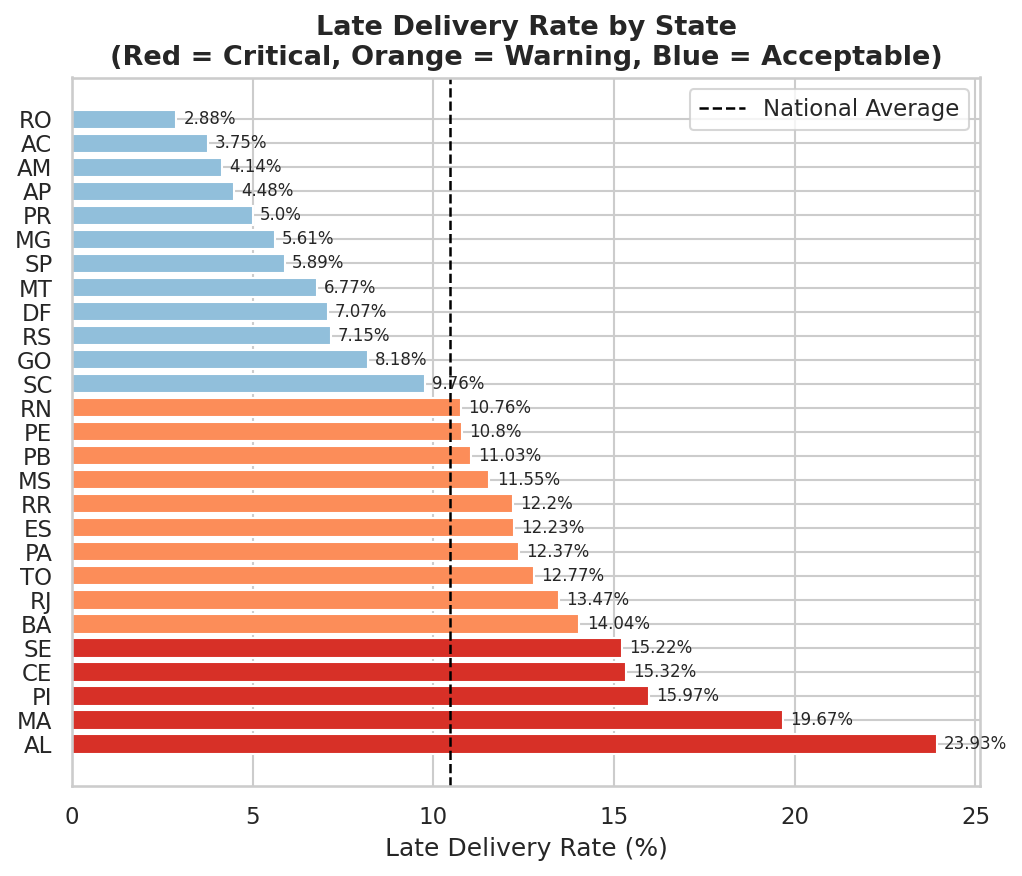

In [33]:
# CHART 1: Late % by State (Horizontal Bar)

fig, ax = plt.subplots(figsize=(7, 6))

colors = ['#d73027' if x > 15 else '#fc8d59' if x > 10 else '#91bfdb'
          for x in state_analysis['late_pct']]

bars = ax.barh(state_analysis['customer_state'],
               state_analysis['late_pct'],
               color=colors)

ax.axvline(x=state_analysis['late_pct'].mean(),
           color='black', linestyle='--', linewidth=1.2, label='National Average')

ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by State\n(Red = Critical, Orange = Warning, Blue = Acceptable)',
             fontsize=13, fontweight='bold')
ax.legend()

for bar, val in zip(bars, state_analysis['late_pct']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart1_late_by_state.png', bbox_inches='tight')
plt.show()

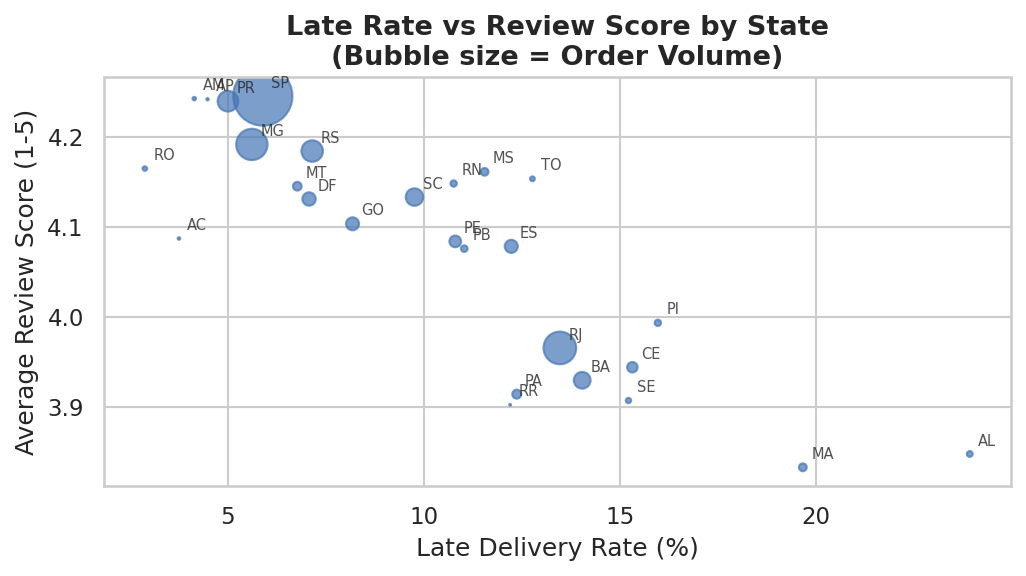

In [34]:
# CHART 2: Late % vs Average Review Score

fig, ax = plt.subplots(figsize=(7, 4))

scatter = ax.scatter(state_analysis['late_pct'],
                     state_analysis['avg_review_score'],
                     s=state_analysis['total_orders']/50,
                     alpha=0.7,
                     color='#4575b4')

# Label each bubble with state name
for _, row in state_analysis.iterrows():
    ax.annotate(row['customer_state'],
                (row['late_pct'], row['avg_review_score']),
                fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('Average Review Score (1-5)')
ax.set_title('Late Rate vs Review Score by State\n(Bubble size = Order Volume)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_late_vs_review.png', bbox_inches='tight')
plt.show()

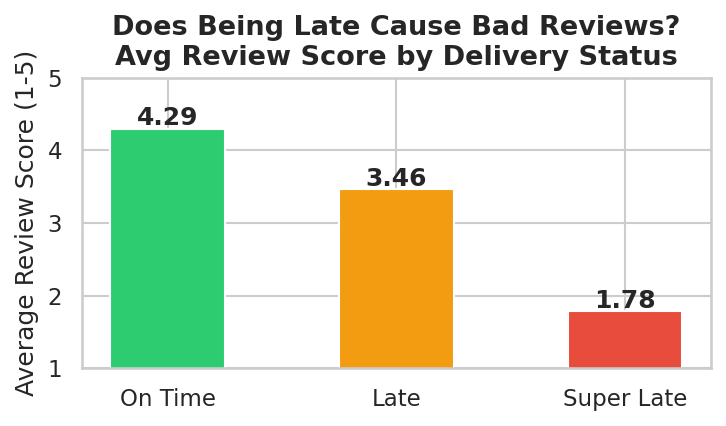

In [35]:
# CHART 3: Average Review Score by Delivery Status

status_review = master_df.groupby('delivery_status')['review_score'].mean().reset_index()
status_order = ['On Time', 'Late', 'Super Late']
status_review['delivery_status'] = pd.Categorical(
    status_review['delivery_status'], categories=status_order, ordered=True)
status_review = status_review.sort_values('delivery_status')

fig, ax = plt.subplots(figsize=(5, 3))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(status_review['delivery_status'],
              status_review['review_score'],
              color=colors, width=0.5)

ax.set_ylim(1, 5)
ax.set_ylabel('Average Review Score (1-5)')
ax.set_title('Does Being Late Cause Bad Reviews?\nAvg Review Score by Delivery Status',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, status_review['review_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_review_by_status.png', bbox_inches='tight')
plt.show()

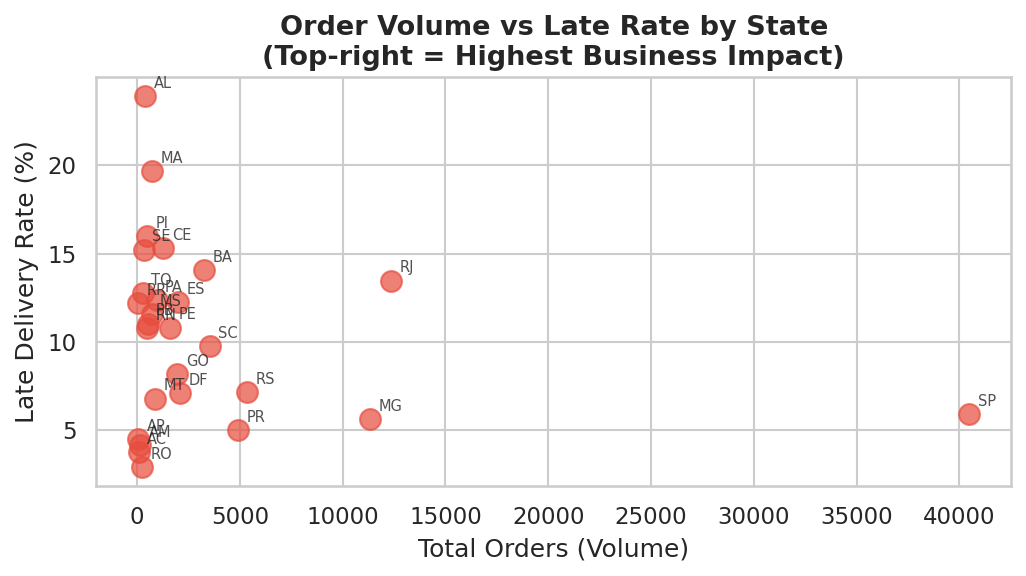

In [36]:
# CHART 4: Order Volume vs Late Rate

fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(state_analysis['total_orders'],
           state_analysis['late_pct'],
           s=100, alpha=0.7, color='#e74c3c')

for _, row in state_analysis.iterrows():
    ax.annotate(row['customer_state'],
                (row['total_orders'], row['late_pct']),
                fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Total Orders (Volume)')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('Order Volume vs Late Rate by State\n(Top-right = Highest Business Impact)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_volume_vs_laterate.png', bbox_inches='tight')
plt.show()

# Candidate's Choice: ANOMALY DETECTION: Monthly Late Rate by State

In [38]:
# Extracting year-month from purchase timestamp
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

# Calculating late rate per state per month
monthly_state = master_df.groupby(['customer_state', 'order_month']).agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum')
).reset_index()

monthly_state['late_pct'] = (
    monthly_state['late_orders'] / monthly_state['total_orders'] * 100
).round(2)

# Checking how many months of data each state has
months_per_state = monthly_state.groupby('customer_state')['order_month'].count()
print("Months of data per state:")
print(months_per_state.sort_values(ascending=False).to_string())

# Checking average orders per month per state
avg_orders_per_month = monthly_state.groupby('customer_state')['total_orders'].mean()
print("\nAvg orders per month per state:")
print(avg_orders_per_month.sort_values(ascending=False).round(1).to_string())

Months of data per state:
customer_state
PR    22
SP    22
AL    21
MA    21
GO    21
DF    21
ES    21
MG    21
PB    21
CE    21
BA    21
SE    21
RN    21
SC    21
MT    21
PI    21
PE    21
RJ    21
PA    21
RS    21
MS    20
AC    20
RO    20
TO    20
AM    19
AP    18
RR    17

Avg orders per month per state:
customer_state
SP    1840.6
RJ     588.1
MG     540.7
RS     254.5
PR     223.8
SC     168.9
BA     155.0
DF      99.0
ES      95.0
GO      93.2
PE      75.9
CE      60.9
PA      45.0
MT      42.2
MS      35.0
MA      34.1
PB      24.6
PI      22.7
RN      22.6
AL      18.9
SE      16.0
TO      13.7
RO      12.2
AM       7.6
AC       4.0
AP       3.7
RR       2.4


In [39]:
# Maintaining Integrity of the data acquired in the first step

# Filter to states with enough data
sufficient_states = avg_orders_per_month[avg_orders_per_month >= 30].index.tolist()
monthly_filtered = monthly_state[monthly_state['customer_state'].isin(sufficient_states)].copy()

print(f"States included: {sufficient_states}")

# Calculate mean and std per state ( each state's normal range)
state_stats = monthly_filtered.groupby('customer_state')['late_pct'].agg(['mean', 'std']).reset_index()
state_stats.columns = ['customer_state', 'mean_late_pct', 'std_late_pct']

# Merge back onto monthly data
monthly_filtered = monthly_filtered.merge(state_stats, on='customer_state')

# Calculate Z-score for each month (how many standard deviations above normal)
monthly_filtered['z_score'] = (
    (monthly_filtered['late_pct'] - monthly_filtered['mean_late_pct']) /
    monthly_filtered['std_late_pct']
)

#Flag anomalies (z-score > 2)
monthly_filtered['is_anomaly'] = monthly_filtered['z_score'] > 2

anomalies = monthly_filtered[monthly_filtered['is_anomaly']].sort_values('z_score', ascending=False)
print(f"\nAnomalies detected: {len(anomalies)}")
print(anomalies[['customer_state', 'order_month', 'late_pct', 'mean_late_pct', 'z_score']].to_string())

States included: ['BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PE', 'PR', 'RJ', 'RS', 'SC', 'SP']

Anomalies detected: 22
    customer_state order_month  late_pct  mean_late_pct   z_score
315             SP     2016-09    100.00       9.440909  4.411785
141             MG     2018-03     23.25       4.143333  3.470944
78              ES     2018-03     44.36       9.750476  3.437955
203             PA     2018-03     52.24       9.761429  3.362588
170             MT     2017-03     37.50       6.595238  3.202502
246             PR     2018-03     15.18       3.936818  2.739407
288             RS     2018-03     20.64       5.632381  2.691776
36              CE     2018-03     53.76      12.836190  2.665344
161             MS     2018-03     40.35       9.000500  2.630859
15              BA     2018-03     35.32      11.929048  2.629585
98              GO     2018-02     21.92       6.377143  2.529905
120             MA     2018-03     55.10      16.805238  2.410294
57  

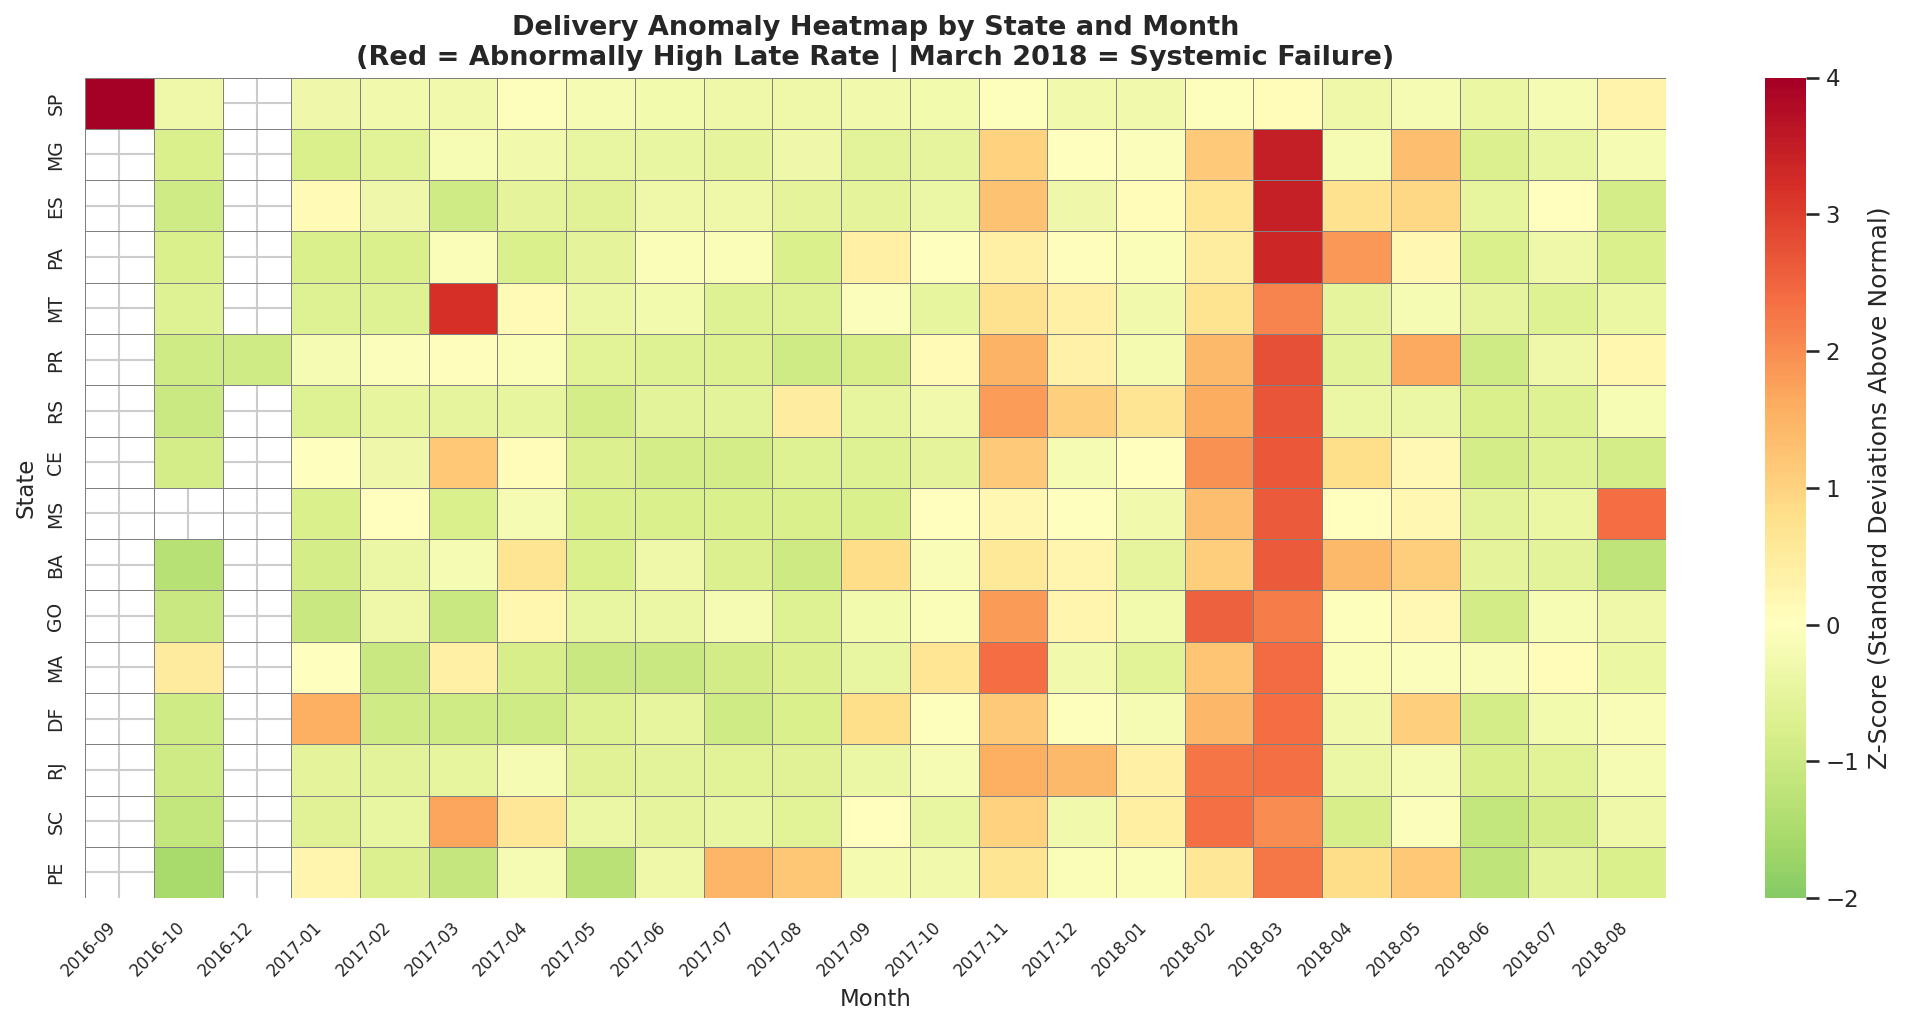

In [41]:
# Plotting the graph

# CHART 5: Anomaly Detection Heatmap

# Pivot data for heatmap
# Convert order_month to string for plotting
monthly_filtered['order_month_str'] = monthly_filtered['order_month'].astype(str)

heatmap_data = monthly_filtered.pivot_table(
    index='customer_state',
    columns='order_month_str',
    values='z_score',
    aggfunc='mean'
)

# Sort states by their max z-score (worst anomalies at top)
heatmap_data = heatmap_data.loc[heatmap_data.max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    cmap='RdYlGn_r',  # Red = bad, Green = good
    center=0,
    vmin=-2,
    vmax=4,
    ax=ax,
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Z-Score (Standard Deviations Above Normal)'}
)

ax.set_title('Delivery Anomaly Heatmap by State and Month\n(Red = Abnormally High Late Rate | March 2018 = Systemic Failure)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('State', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('chart5_anomaly_heatmap.png', bbox_inches='tight')
plt.show()

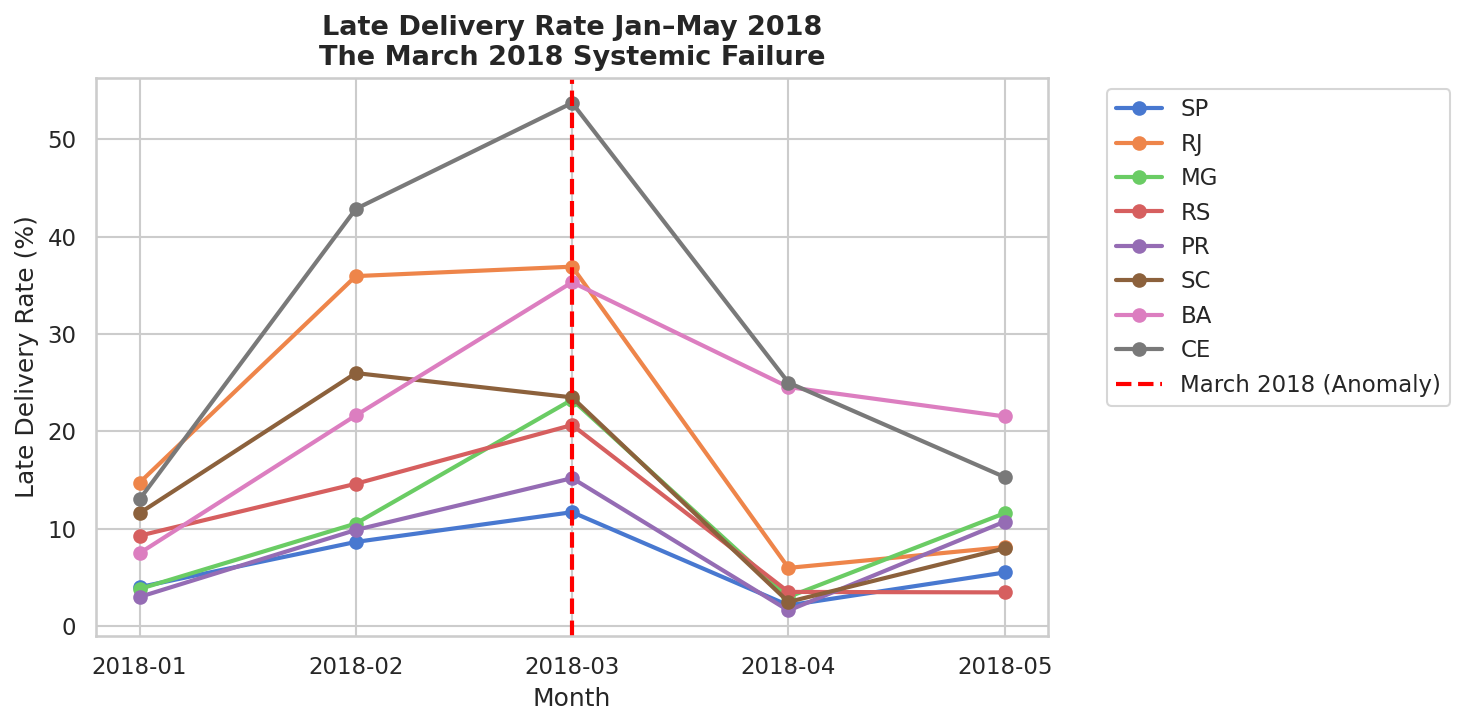

In [45]:
# CHART 6: March 2018 Spike — Before vs During

# Focus on top 8 states by volume
top_states = ['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'CE']

march_comparison = monthly_filtered[
    monthly_filtered['customer_state'].isin(top_states)
][['customer_state', 'order_month_str', 'late_pct', 'mean_late_pct']].copy()

# Filter to just Feb, Mar, Apr 2018 to show the spike
spike_window = march_comparison[
    march_comparison['order_month_str'].isin(['2018-01', '2018-02', '2018-03', '2018-04', '2018-05'])
]

fig, ax = plt.subplots(figsize=(10, 5))

for state in top_states:
    state_data = spike_window[spike_window['customer_state'] == state]
    ax.plot(state_data['order_month_str'], state_data['late_pct'],
            marker='o', label=state, linewidth=2)

ax.axvline(x='2018-03', color='red', linestyle='--', linewidth=2, label='March 2018 (Anomaly)')
ax.set_title('Late Delivery Rate Jan–May 2018\nThe March 2018 Systemic Failure',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Late Delivery Rate (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('chart6_march2018_spike.png', bbox_inches='tight')
plt.show()

# The Bonuc Challenge

In [46]:
# Load the translation file
translations_df = pd.read_csv('/content/drive/MyDrive/Amali/product_category_name_translation.csv')
print(translations_df.shape)
print(translations_df.head(10))

(71, 2)
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor
5           esporte_lazer                sports_leisure
6              perfumaria                     perfumery
7   utilidades_domesticas                    housewares
8               telefonia                     telephony
9      relogios_presentes                 watches_gifts


In [47]:
# Join translations to master_df
master_df = master_df.merge(translations_df, on='product_category_name', how='left')

# Check how many got translated vs still null
print(f"Total rows: {len(master_df)}")
print(f"Translated: {master_df['product_category_name_english'].notna().sum()}")
print(f"Still null: {master_df['product_category_name_english'].isna().sum()}")

# Fill remaining nulls (products with no category get labeled unknown)
master_df['product_category_name_english'] = master_df['product_category_name_english'].fillna('unknown')


Total rows: 96470
Translated: 95092
Still null: 1378


In [48]:
# Analyze late rate per category
category_analysis = master_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_review_score=('review_score', 'mean')
).reset_index()

category_analysis['late_pct'] = (
    category_analysis['late_orders'] / category_analysis['total_orders'] * 100
).round(2)

# Filter to categories with at least 100 orders
category_analysis = category_analysis[category_analysis['total_orders'] >= 100]

# Sort by worst late rate
category_analysis = category_analysis.sort_values('late_pct', ascending=False)

print(f"\nCategories with 100+ orders: {len(category_analysis)}")
print(category_analysis[['product_category_name_english', 'total_orders', 'late_pct', 'avg_review_score']].to_string())


Categories with 100+ orders: 52
              product_category_name_english  total_orders  late_pct  avg_review_score
4                                     audio           344     13.08          3.847507
33                  fashion_underwear_beach           117     12.82          4.008621
10                          books_technical           255     10.98          4.425197
47                             home_confort           370     10.27          3.907609
36                                     food           435     10.11          4.324826
26                              electronics          2507      9.85          4.128617
12                       christmas_supplies           125      9.60          4.113821
6                                      baby          2763      9.34          4.121489
57                         office_furniture          1246      9.23          3.650485
17          construction_tools_construction           728      9.20          4.132780
18                con

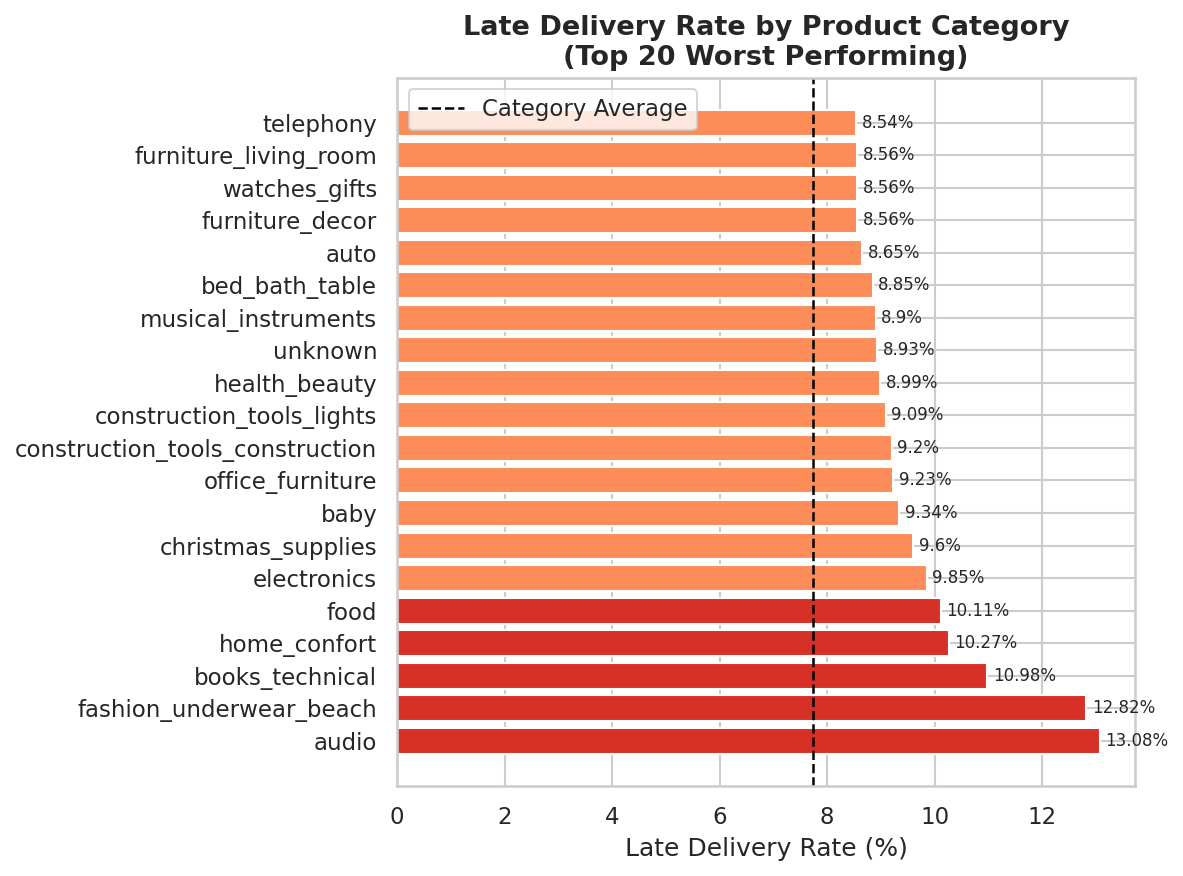

In [50]:
# CHART 7: Late Rate by Product Category

top20_categories = category_analysis.head(20)

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#d73027' if x > 10 else '#fc8d59' if x > 8 else '#91bfdb'
          for x in top20_categories['late_pct']]

bars = ax.barh(top20_categories['product_category_name_english'],
               top20_categories['late_pct'],
               color=colors)

ax.axvline(x=category_analysis['late_pct'].mean(),
           color='black', linestyle='--', linewidth=1.2, label='Category Average')

ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by Product Category\n(Top 20 Worst Performing)',
             fontsize=13, fontweight='bold')
ax.legend()

for bar, val in zip(bars, top20_categories['late_pct']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart7_late_by_category.png', bbox_inches='tight')
plt.show()

In [51]:
# Removing duplicates again after translations join
print(f"Before deduplication: {master_df.shape}")

master_df = master_df.drop_duplicates(subset='order_id', keep='first')

print(f"After deduplication: {master_df.shape}")

Before deduplication: (96470, 26)
After deduplication: (96470, 26)


# Saving The Datasets To Google Drive

In [ ]:
# Create the folder first
os.makedirs('/content/drive/MyDrive/Amali/new_data', exist_ok=True)

# Now export all files
master_df.to_csv('/content/drive/MyDrive/Amali/new_data/master_df.csv', index=False)
state_analysis.to_csv('/content/drive/MyDrive/Amali/new_data/state_analysis.csv', index=False)
category_analysis.to_csv('/content/drive/MyDrive/Amali/new_data/category_analysis.csv', index=False)

monthly_filtered['order_month_str'] = monthly_filtered['order_month'].astype(str)
monthly_filtered.to_csv('/content/drive/MyDrive/Amali/new_data/monthly_state.csv', index=False)

print("All files exported successfully!")

All files exported successfully!
